In [1]:
import pandas as pd

class TreeNode:
    def __init__(self, name):
        self.name = name
        self.children = {}
        self.metadata = {}

    def add_child(self, node_name):
        if node_name not in self.children:
            self.children[node_name] = TreeNode(node_name)
        return self.children[node_name]

def build_tree_from_taxonomy(
    csv_path: str,
    resolution_cols: list[str],
    annotation_cols: list[str] | None = None
) -> TreeNode:
    df = pd.read_csv(csv_path, dtype=str).fillna("")
    if annotation_cols is None:
        # everything not in resolutions becomes metadata
        annotation_cols = [c for c in df.columns if c not in resolution_cols]
    root = TreeNode("root")
    for _, row in df.iterrows():
        node = root
        # descend/create according to each resolution column
        for col in resolution_cols:
            val = row[col]
            if not val:
                break
            node = node.add_child(val)
        # attach all other columns as metadata on the leaf
        for col in annotation_cols:
            node.metadata[col] = row[col]
    return root


In [2]:
path = "/Users/kylekimler/Projects/GCA/ontology/gca_celltype_taxonomy.csv"
resolutions = ["Lineage", "Differentia", "Habitus", "Status", "Whim"]
extras = ["closest_GCA_celltype", "markers"]
tree = build_tree_from_taxonomy(path, resolutions, extras)


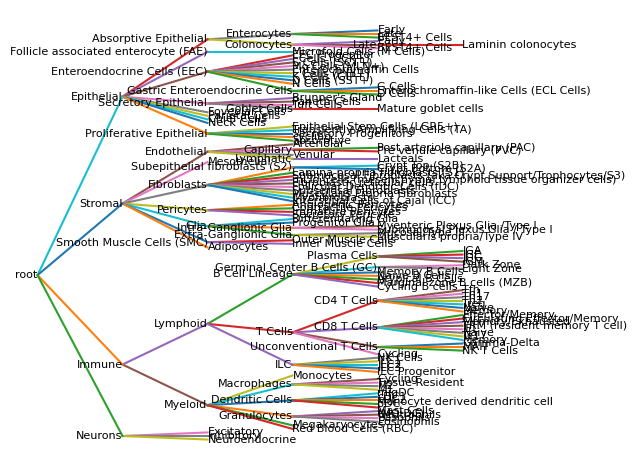

In [3]:
import matplotlib.pyplot as plt

def pretty_print(node, indent=0):
    """Recursively print out node names with indentation."""
    print("  " * indent + node.name)
    for child in node.children.values():
        pretty_print(child, indent + 1)


def plot_tree(node):
    """
    Assign each node an (x,y) based on depth and leaf order,
    then draw lines + labels in matplotlib.
    """
    # 1) Compute positions
    positions = {}
    def _assign(n, depth=0, counter=[0]):
        # if leaf, give it the next y
        if not n.children:
            y = counter[0]
            positions[n] = (depth, y)
            counter[0] += 1
        else:
            # assign positions for children first
            child_ys = []
            for c in n.children.values():
                _assign(c, depth + 1, counter)
                child_ys.append(positions[c][1])
            # place this node midway between its children
            positions[n] = (depth, sum(child_ys) / len(child_ys))
    _assign(node)

    # 2) Plot edges
    fig, ax = plt.subplots()
    for parent, (x1, y1) in positions.items():
        for child in parent.children.values():
            x2, y2 = positions[child]
            ax.plot([x1, x2], [y1, y2])  # default color

    # 3) Plot labels
    for n, (x, y) in positions.items():
        ax.text(x, y, n.name, va="center", ha="right" if n.children else "left",
                fontsize=8)

    ax.invert_yaxis()   # so top of tree is at the top
    ax.axis("off")
    plt.tight_layout()
    plt.show()

plot_tree(tree)

/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_23580/1539144706.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,0.9,1])


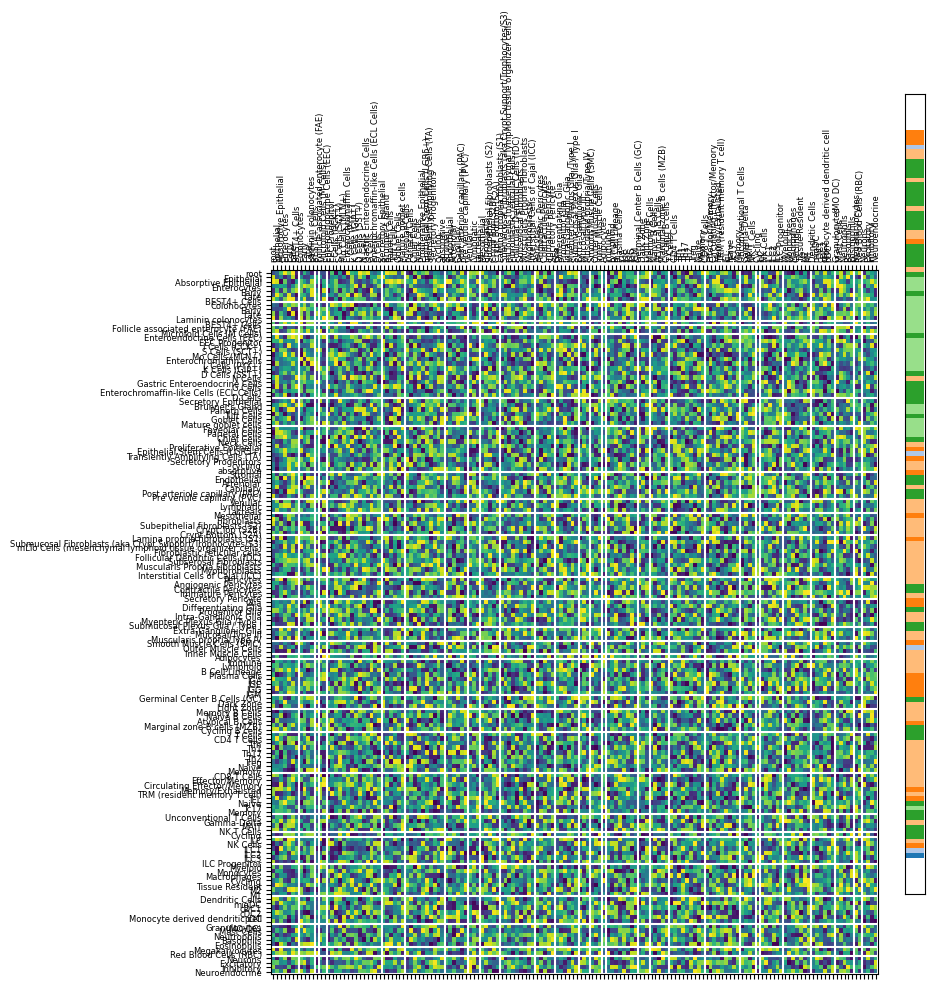

In [4]:
def flatten(node, order, depths, depth=0):
    order.append(node)
    depths.append(depth)
    for child in node.children.values():
        flatten(child, order, depths, depth+1)
    return order, depths

# 1) flatten
nodes, depths = flatten(tree, [], [])

# 2) build your matrix (here random for demo)
import pandas as pd, numpy as np
M = pd.DataFrame(
    np.random.rand(len(nodes), len(nodes)),
    index=[n.name for n in nodes],
    columns=[n.name for n in nodes]
)

# 3) find boundaries at a given depth, e.g. depth=1
boundaries = []
last = depths[0]
for i,d in enumerate(depths):
    if d < last:
        boundaries.append(i)
    last = d
# also add final boundary
boundaries.append(len(nodes))

# 4) plot with separators
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,10))
cax = ax.matshow(M, aspect='auto')
for b in boundaries:
    ax.axhline(b-0.5, color='white')
    ax.axvline(b-0.5, color='white')

# optional side‑bar for depth
ax2 = fig.add_axes([0.91, 0.1, 0.02, 0.8])
ax2.barh(range(len(nodes)), [1]*len(nodes), height=1, 
         left=0, color=plt.cm.tab20(depths))
ax2.set_xticks([])
ax2.set_yticks([])

ax.set_xticks(range(len(nodes)))
ax.set_xticklabels([n.name for n in nodes], rotation=90, fontsize=6)
ax.set_yticks(range(len(nodes)))
ax.set_yticklabels([n.name for n in nodes], fontsize=6)

plt.tight_layout(rect=[0,0,0.9,1])
plt.show()


In [9]:
<div style="overflow: auto; max-height: 600px;">

%matplotlib inline
import matplotlib.pyplot as plt

# compute figure size as before
n = len(nodes)
fs = 6
scale = fs / 5
w = max(8, n * scale)
h = max(8, n * scale)

fig, ax = plt.subplots(figsize=(w, h))
cax = ax.matshow(M, aspect='auto')

for b in boundaries:
    ax.axhline(b - 0.5, color='white', lw=1)
    ax.axvline(b - 0.5, color='white', lw=1)

ax.set_xticks(range(n))
ax.set_xticklabels([n.name for n in nodes], rotation=90, fontsize=fs)
ax.set_yticks(range(n))
ax.set_yticklabels([n.name for n in nodes], fontsize=fs)

ax.invert_yaxis()
ax.axis('off')
plt.tight_layout()
plt.show()


In [13]:
# %pip install ipympl
%pip install jupyter-matplotlib

ERROR: Could not find a version that satisfies the requirement jupyter-matplotlib (from versions: none)
ERROR: No matching distribution found for jupyter-matplotlib
Note: you may need to restart the kernel to use updated packages.
